## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  


# Visualizing Urban Areas

This notebook demonstrates how to locate urban areas and individual buildings using Sentinel‑1 GRD VH and VV polarizations. VH and VV backscatter are mapped to RGB so that different building types appear in distinctive colors: VV is shown in the green channel, VH in the blue channel, and only strongly reflecting VH values (VH > 0.5) are added to the red channel. As a result, buildings appear purple (dominated by VH), green (dominated by VV), or white (strong in both), which helps separate them from surrounding terrain and supports tasks such as tracking urban expansion, estimating building types, or identifying buildings at risks of natural disturbances (e.g. flood). The method performs less reliably in high‑elevation regions, where snow and steep slopes can also appear bright in VH and VV, and make urban areas harder to distinguish.

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing terrestrial land
3. Load Sentinel-1 GRD imagery for a specific date, using VH and VV polarizations
4. Define the RGB composite:
    - VV is placed in the green channel
    - VH is placed in the blue channel
    - Only high VH values (VH > 0.5) are added to the red channel
5. Visualize buildings and urban areas, which appear purple (strong VH), green (strong VV), or white (strong in both)


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [4]:
import openeo
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create, if_

## Connect to OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [5]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of Bologna, Italy

In [6]:
spatial_extent = {"west" : 11.20, "south" : 44.45, "east" : 11.48, "north" : 44.56}

## Load Sentinel-1 Data

Sentinel-1 imagery is provided by two polar-orbiting satellites, operating day and night performing C-band synthetic aperture radar imaging that enables image acquisition regardless of the weather. Its applications include monitoring sea ice, oil spills, land-use change, among others [SentinelHub documentations](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel/sentinel-1/)

In [7]:
s1cube = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    temporal_extent=["2019-05-26", "2019-05-30"], 
    bands=[
        "VH",
        "VV"
    ],
)

# Filter for a specific date
s1cube = s1cube.reduce_dimension(dimension="t", reducer="first")

In [8]:
def urban_viz(data):
    VH, VV = (data[0], data[1])

    red_output = if_(
        (5.5 * VH) > 0.5,
        1,
        0
    )

    green_output = VV

    blue_output = VH * 8

    output = array_create([
        red_output,
        green_output,
        blue_output
    ])

    return output

In [9]:
urban_image = s1cube.apply_dimension(
    dimension="bands",
    process=urban_viz
)

urban_image = urban_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

urban_image = urban_image.save_result("PNG")

In [10]:
# Send job to backend and download the result
urban_image.download("urban_areas.png")

## Visualize the Result

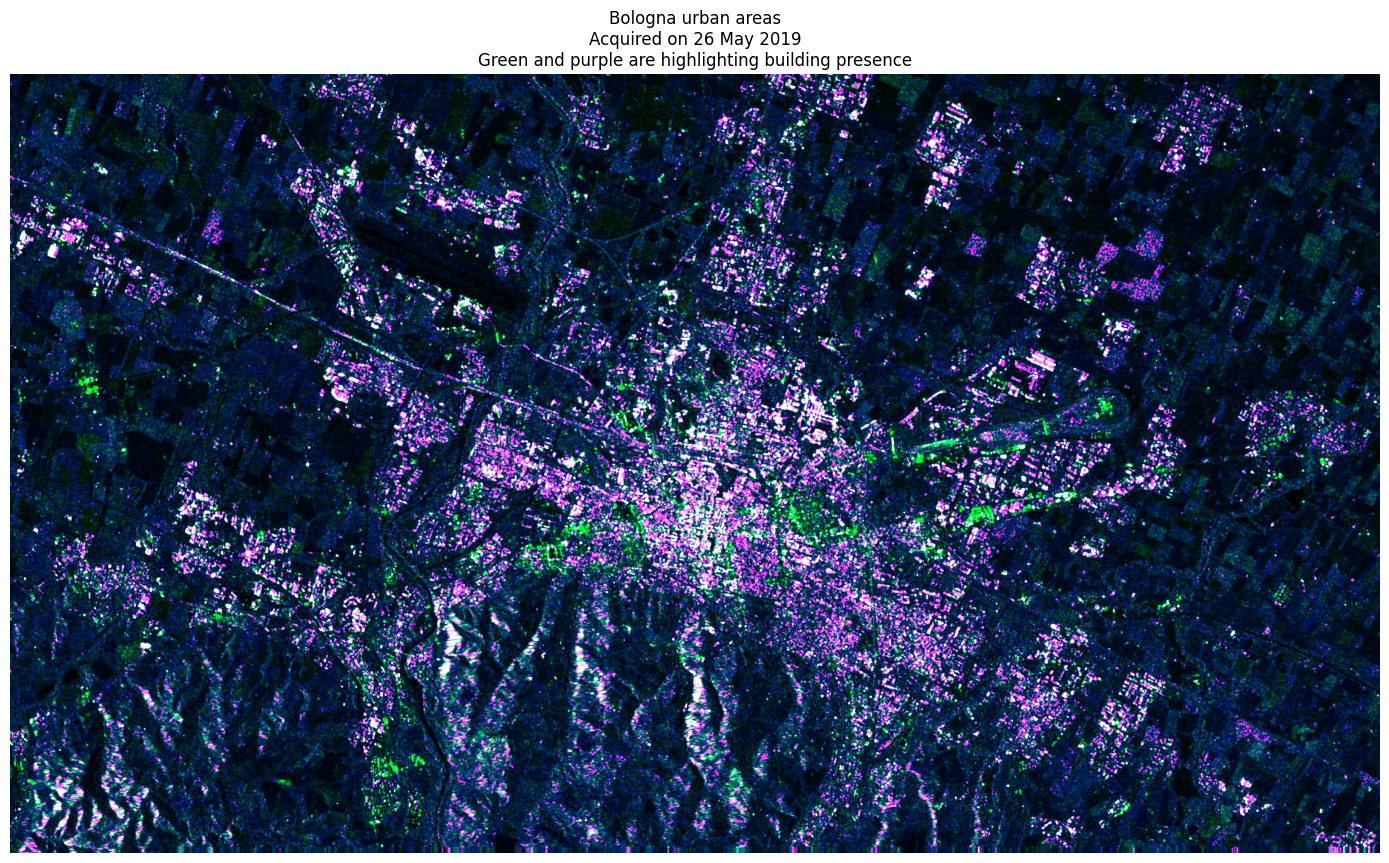

In [11]:
# Load and display the image
img = Image.open("urban_areas.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Bologna urban areas\n"
    "Acquired on 26 May 2019\n"
    "Green and purple are highlighting building presence",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Urban Areas Script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/)

**Author:** Monja B. Šebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.

## Conclusion

This notebook demonstrates the implementation of Urban Area estimation for mapping buildings using openEO and Sentinel-1 imagery. The notebook succesfully:

- Identifies urban areas using VV and VH polarizations
- Produces color-mapped visualizations

The approach can be extended to:

- Create time-series animations to track urban area changes
- Integrate the outputs into early-warning systems from natural disturbances
- Support modelling of the spread and intensity of natural disturbances under varying climate conditions that would affect cities